In [50]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchmetrics import MeanAbsoluteError
from torch.utils.data import TensorDataset, DataLoader
print(f'PyTorch Version: {torch.__version__}')
print(f'CUDA Available: {torch.cuda.is_available()}')
print(f'GPU: {torch.cuda.get_device_name(0)}')

PyTorch Version: 2.9.1+cu128
CUDA Available: True
GPU: NVIDIA GeForce RTX 5080


In [51]:
import os
print(os.listdir('modelD/processed_tensors/caseC'))

['valid_data.pt', 'label_stats.pt', 'train_data.pt', 'test_data.pt']


In [52]:
def load_data():
    # 加载训练数据
    train_data = torch.load('modelD/processed_tensors/caseC/train_data.pt')
    train_dataset = TensorDataset(train_data['images'], train_data['labels'])
    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

    valid_data = torch.load('modelD/processed_tensors/caseC/valid_data.pt')
    valid_dataset = TensorDataset(valid_data['images'], valid_data['labels'])
    valid_loader = DataLoader(valid_dataset, batch_size=32, shuffle=True)

    test_data = torch.load('modelD/processed_tensors/caseC/test_data.pt')
    test_dataset = TensorDataset(test_data['images'], test_data['labels'])
    test_loader = DataLoader(test_dataset, batch_size=32, shuffle=True)

    # 验证样本数量
    expected_sizes = {'train': 28800, 'valid': 3600, 'test': 3600}
    for dataset_type, dataset, data in [
        ('train', train_dataset, train_data),
        ('valid', valid_dataset, valid_data),
        ('test', test_dataset, test_data)
    ]:
        actual_size = len(dataset)
        expected_size = expected_sizes[dataset_type]
        if actual_size != expected_size:
            print(f"警告：{dataset_type} 数据集样本数量 ({actual_size}) 与预期 ({expected_size}) 不符！")

    print(train_data['images'].shape)  # 预期：(7200, 1, 20, 39)
    print(train_data['labels'].shape)  # 预期：(7200,)
    print(f"训练集: {len(train_dataset)} 样本, 数据形状 {train_dataset[0][0].shape}")
    print(f"验证集: {len(valid_dataset)} 样本, 数据形状 {valid_dataset[0][0].shape}")
    print(f"测试集: {len(test_dataset)} 样本, 数据形状 {test_dataset[0][0].shape}")
    return train_loader, valid_loader, test_loader

if __name__ == "__main__":
    train_loader, valid_loader, test_loader = load_data()

torch.Size([28800, 1, 20, 40])
torch.Size([28800, 2])
训练集: 28800 样本, 数据形状 torch.Size([1, 20, 40])
验证集: 3600 样本, 数据形状 torch.Size([1, 20, 40])
测试集: 3600 样本, 数据形状 torch.Size([1, 20, 40])


In [53]:
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        # 输入形状 (1, 20, 40)
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)  # 输出 (32, 20, 40)
        self.bn1 = nn.BatchNorm2d(32)  # 批归一化
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool2d(2)  # 输出 (32, 10, 20)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)  # 输出 (64, 10, 20)
        self.bn2 = nn.BatchNorm2d(64)  # 批归一化
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool2d(2)  # 输出 (64, 5, 10)
        self.flatten = nn.Flatten()
        # 计算全连接层输入维度：5 * 10 * 64 = 3200
        self.fc1 = nn.Linear(5 * 10 * 64, 256)  # 更新为3200
        self.relu3 = nn.ReLU()
        self.dropout = nn.Dropout(0.4)  # 可根据验证集性能调整到0.1-0.4
        self.fc2 = nn.Linear(256, 2)  # 双输出，回归任务 (klw, mcool)

    def forward(self, x):
        x = self.pool1(self.relu1(self.bn1(self.conv1(x))))
        x = self.pool2(self.relu2(self.bn2(self.conv2(x))))
        x = self.flatten(x)
        x = self.relu3(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

In [54]:
import pandas as pd
import os
from torch.optim.lr_scheduler import ReduceLROnPlateau

def r2_score(y_true, y_pred):
    ss_res = torch.sum((y_true - y_pred) ** 2)
    ss_tot = torch.sum((y_true - torch.mean(y_true)) ** 2)
    return 1 - (ss_res / ss_tot) if ss_tot > 0 else torch.tensor(0.0)

def train_model(model, train_loader, valid_loader, 
                epochs=200, patience=30, 
                w_klw=1.0, w_mcool=1.0,
                save_csv_path='modelD/training_history_caseC.csv'):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Using device: {device}")
    
    model = model.to(device)
    criterion = nn.SmoothL1Loss(beta=0.1)
    mae = MeanAbsoluteError().to(device)
    optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-3)
    scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=8, min_lr=1e-6)

    best_valid_loss = float('inf')
    early_stop_counter = 0

    # 用于记录训练历史的字典
    history = {
        'epoch': [],
        'train_loss': [],
        'train_mae_klw': [], 'train_mae_mcool': [],
        'valid_loss': [],
        'valid_mae_klw': [], 'valid_mae_mcool': [],
        'valid_r2_klw': [], 'valid_r2_mcool': []
    }

    for epoch in range(epochs):
        # =================== Training ===================
        model.train()
        train_loss = 0.0
        train_mae_klw = 0.0
        train_mae_mcool = 0.0
        train_samples = 0

        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            output = model(x)  # (B, 2)
            
            loss_klw = criterion(output[:, 0], y[:, 0]) * w_klw
            loss_mcool = criterion(output[:, 1], y[:, 1]) * w_mcool
            loss = loss_klw + loss_mcool
            
            loss.backward()
            optimizer.step()
            
            batch_size = x.size(0)
            train_loss += loss.item() * batch_size
            train_mae_klw += mae(output[:, 0], y[:, 0]).item() * batch_size
            train_mae_mcool += mae(output[:, 1], y[:, 1]).item() * batch_size
            train_samples += batch_size
        
        train_loss /= train_samples
        train_mae_klw /= train_samples
        train_mae_mcool /= train_samples

        # =================== Validation ===================
        model.eval()
        valid_loss = 0.0
        valid_mae_klw = 0.0
        valid_mae_mcool = 0.0
        valid_samples = 0
        all_preds = []
        all_trues = []
        
        with torch.no_grad():
            for x, y in valid_loader:
                x, y = x.to(device), y.to(device)
                output = model(x)
                
                loss_klw = criterion(output[:, 0], y[:, 0]) * w_klw
                loss_mcool = criterion(output[:, 1], y[:, 1]) * w_mcool
                loss = loss_klw + loss_mcool
                
                batch_size = x.size(0)
                valid_loss += loss.item() * batch_size
                valid_mae_klw += mae(output[:, 0], y[:, 0]).item() * batch_size
                valid_mae_mcool += mae(output[:, 1], y[:, 1]).item() * batch_size
                valid_samples += batch_size
                
                all_preds.append(output.cpu())
                all_trues.append(y.cpu())
        
        valid_loss /= valid_samples
        valid_mae_klw /= valid_samples
        valid_mae_mcool /= valid_samples
        
        all_pred = torch.cat(all_preds, dim=0)
        all_true = torch.cat(all_trues, dim=0)
        valid_r2_klw = r2_score(all_true[:, 0], all_pred[:, 0]).item()
        valid_r2_mcool = r2_score(all_true[:, 1], all_pred[:, 1]).item()

        # =================== Record History ===================
        history['epoch'].append(epoch + 1)
        history['train_loss'].append(train_loss)
        history['train_mae_klw'].append(train_mae_klw)
        history['train_mae_mcool'].append(train_mae_mcool)
        history['valid_loss'].append(valid_loss)
        history['valid_mae_klw'].append(valid_mae_klw)
        history['valid_mae_mcool'].append(valid_mae_mcool)
        history['valid_r2_klw'].append(valid_r2_klw)
        history['valid_r2_mcool'].append(valid_r2_mcool)

        print(f'Epoch {epoch+1:3d}/{epochs} | '
              f'Train Loss: {train_loss:.4f} | Train MAE klw: {train_mae_klw:.4f} | Train MAE mcool: {train_mae_mcool:.4f} | '
              f'Valid Loss: {valid_loss:.4f} | Valid MAE klw: {valid_mae_klw:.4f} | Valid MAE mcool: {valid_mae_mcool:.4f} | '
              f'Valid R² klw: {valid_r2_klw:.4f} | Valid R² mcool: {valid_r2_mcool:.4f}')

        # =================== Early Stopping & Save Best ===================
        scheduler.step(valid_loss)
        if valid_loss < best_valid_loss:
            best_valid_loss = valid_loss
            os.makedirs(os.path.dirname('modelD/best_model_caseC.pt'), exist_ok=True)
            torch.save(model.state_dict(), 'modelD/best_model_caseC.pt')
            early_stop_counter = 0
            print("  → New best model saved!")
        else:
            early_stop_counter += 1
            if early_stop_counter >= patience:
                print(f"\nEarly stopping triggered at epoch {epoch+1}")
                break

    # =================== Save History to CSV ===================
    if save_csv_path:
        os.makedirs(os.path.dirname(save_csv_path), exist_ok=True)
        df_history = pd.DataFrame(history)
        df_history.to_csv(save_csv_path, index=False)
        print(f"\nTraining history saved to: {save_csv_path}")

    # 加载最佳模型
    print("Loading best model weights...")
    model.load_state_dict(torch.load('modelD/best_model_caseC.pt'))
    
    return model, history  # 返回模型和历史记录

In [55]:
import numpy as np
np.random.seed(100000)

def test_model(model, test_loader, w_klw=1.0, w_mcool=1):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model.eval()
    criterion = nn.SmoothL1Loss(beta=0.1)
    mae = MeanAbsoluteError().to(device)  # MAE指标
    test_loss, test_mae_klw, test_mae_mcool = 0.0, 0.0, 0.0
    test_samples = 0
    predictions, trues = [], []

    with torch.no_grad():
        for x, y in test_loader:
            x, y = x.to(device), y.to(device)  # x: (batch_size, 1, 20, 40), y: (batch_size, 2)
            output = model(x)  # output: (batch_size, 2)
            
            # 计算加权损失
            loss_klw = criterion(output[:, 0], y[:, 0]) * w_klw  # klw的损失
            loss_mcool = criterion(output[:, 1], y[:, 1]) * w_mcool  # mcool的损失
            loss = loss_klw + loss_mcool
            
            # 累积损失和MAE
            test_loss += loss.item() * x.size(0)
            test_mae_klw += mae(output[:, 0], y[:, 0]).item() * x.size(0)
            test_mae_mcool += mae(output[:, 1], y[:, 1]).item() * x.size(0)
            test_samples += x.size(0)
            
            # 存储预测和真实值
            predictions.append(model(x.to(device)).cpu())  # (batch_size, 2)
            trues.append(y.cpu())  # (batch_size, 2)
        all_pred = torch.cat(predictions, dim=0)
        all_true = torch.cat(trues, dim=0)
        test_r2_klw = r2_score(all_true[:, 0], all_pred[:, 0])
        test_r2_mcool = r2_score(all_true[:, 1], all_pred[:, 1])

    test_loss /= test_samples
    test_mae_klw /= test_samples
    test_mae_mcool /= test_samples
    predictions = np.concatenate(predictions, axis=0)  # 形状：(N, 2)
    trues = np.concatenate(trues, axis=0)  # 形状：(N, 2)

    print(f'Test Loss: {test_loss:.4f}, Test MAE klw: {test_mae_klw:.4f}, Test MAE mcool: {test_mae_mcool:.4f}, Test R2 klw: {test_r2_klw:.4f}, Test R2 mcool: {test_r2_mcool:.4f}')
    return test_loss, test_mae_klw, test_mae_mcool, predictions, trues

In [56]:
# 加载数据
train_loader, valid_loader, test_loader = load_data()

# 初始化模型
model = CNN()

# 训练（使用归一化标签，权重设为1.0）
model, history = train_model(
    model, train_loader, valid_loader,
    epochs=200,
    patience=30,
    w_klw=1.0,
    w_mcool=1.0,
    save_csv_path='modelD/training_history_caseC.csv'
)

# 加载最佳模型
model.load_state_dict(torch.load('modelD/best_model_caseC.pt'))

# 测试
test_loss, test_mae_klw, test_mae_mcool, predictions, trues = test_model(model, test_loader, w_klw=1.0, w_mcool=1.0)

# 反归一化
label_stats = torch.load('modelD/processed_tensors/caseC/label_stats.pt')
mean, std = label_stats['mean'], label_stats['std']
predictions = predictions * std.numpy() + mean.numpy()
trues = trues * std.numpy() + mean.numpy()

# 打印结果
print("部分测试集预测值与真实值（klw, mcool）：")
for i in range(min(5, len(predictions))):
    print(f"样本 {i+1}: 预测值=[{predictions[i, 0]:.4f}, {predictions[i, 1]:.4e}], "
          f"真实值=[{trues[i, 0]:.4f}, {trues[i, 1]:.4e}]")

torch.Size([28800, 1, 20, 40])
torch.Size([28800, 2])
训练集: 28800 样本, 数据形状 torch.Size([1, 20, 40])
验证集: 3600 样本, 数据形状 torch.Size([1, 20, 40])
测试集: 3600 样本, 数据形状 torch.Size([1, 20, 40])
Using device: cuda
Epoch   1/200 | Train Loss: 1.1916 | Train MAE klw: 0.6066 | Train MAE mcool: 0.6818 | Valid Loss: 1.0611 | Valid MAE klw: 0.5339 | Valid MAE mcool: 0.6244 | Valid R² klw: 0.5647 | Valid R² mcool: 0.2538
  → New best model saved!
Epoch   2/200 | Train Loss: 1.1650 | Train MAE klw: 0.5949 | Train MAE mcool: 0.6670 | Valid Loss: 1.0785 | Valid MAE klw: 0.5361 | Valid MAE mcool: 0.6392 | Valid R² klw: 0.5274 | Valid R² mcool: 0.2501
Epoch   3/200 | Train Loss: 1.1632 | Train MAE klw: 0.5936 | Train MAE mcool: 0.6663 | Valid Loss: 1.0881 | Valid MAE klw: 0.5495 | Valid MAE mcool: 0.6349 | Valid R² klw: 0.5549 | Valid R² mcool: 0.2959
Epoch   4/200 | Train Loss: 1.1610 | Train MAE klw: 0.5941 | Train MAE mcool: 0.6637 | Valid Loss: 1.0691 | Valid MAE klw: 0.5367 | Valid MAE mcool: 0.6296 | V

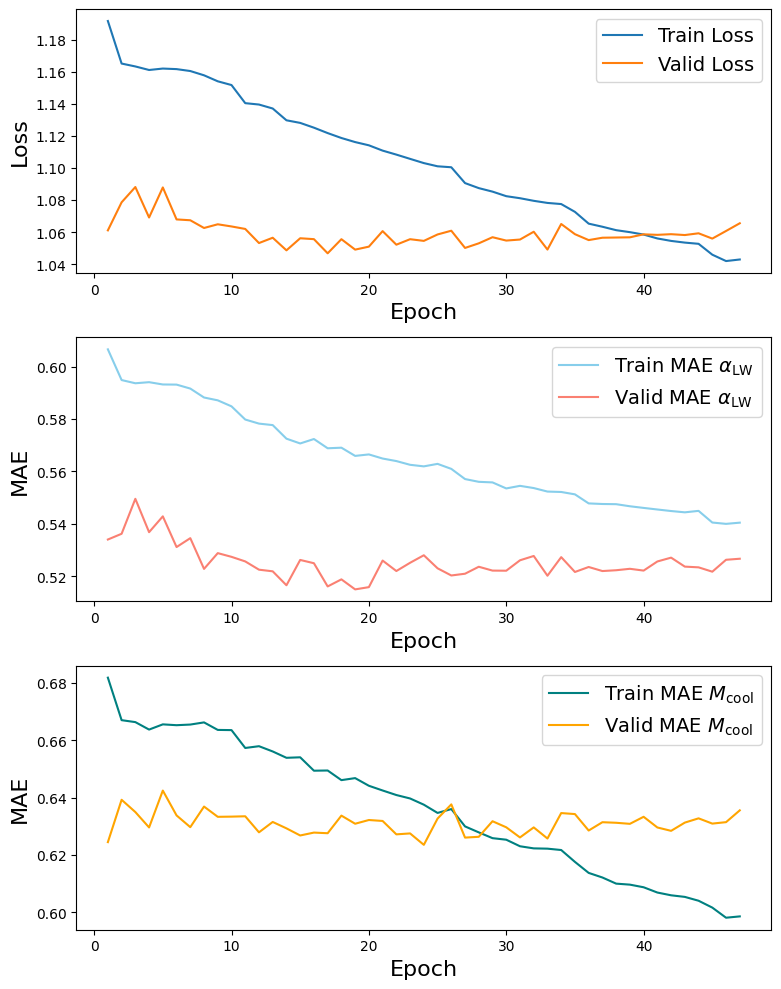

In [104]:
import matplotlib.pyplot as plt

df = pd.DataFrame(history)

plt.figure(figsize=(8, 10))

plt.subplot(3, 1, 1)
plt.plot(df['epoch'], df['train_loss'], label='Train Loss')
plt.plot(df['epoch'], df['valid_loss'], label='Valid Loss')
plt.xlabel('Epoch', fontsize=16)
plt.ylabel('Loss', fontsize=16)
plt.legend(fontsize=14)

plt.subplot(3, 1, 2)
plt.plot(df['epoch'], df['train_mae_klw'], label='Train MAE $\\alpha_\\mathrm{LW}$', color='skyblue')
plt.plot(df['epoch'], df['valid_mae_klw'], label='Valid MAE $\\alpha_\\mathrm{LW}$', color='salmon')
plt.xlabel('Epoch', fontsize=16)
plt.ylabel('MAE', fontsize=16)
plt.legend(fontsize=14)

plt.subplot(3, 1, 3)
plt.plot(df['epoch'], df['train_mae_mcool'], label='Train MAE $M_{\mathrm{cool}}$', color='teal')
plt.plot(df['epoch'], df['valid_mae_mcool'], label='Valid MAE $M_{\mathrm{cool}}$', color='orange')
plt.xlabel('Epoch', fontsize=16)
plt.ylabel('MAE', fontsize=16)
plt.legend(fontsize=14)

plt.tight_layout()
plt.savefig('modelD/traininghistory_CaseC.pdf', dpi=300, bbox_inches='tight')
plt.show()

In [65]:
# 加载数据（仅测试集）
_, _, test_loader = load_data()

# 初始化模型并加载最佳权重
model = CNN()
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)
model.load_state_dict(torch.load('modelD/best_model_caseC.pt'))
model.eval()

# 测试模型，获取预测和真实值
test_loss, test_mae_klw, test_mae_mcool, predictions, trues = test_model(model, test_loader, w_klw=1.0, w_mcool=1.0)

# 反归一化
label_stats = torch.load('modelD/processed_tensors/caseC/label_stats.pt')
mean = label_stats['mean']  # [klw_mean, mcool_mean]
std = label_stats['std']    # [klw_std, mcool_std]
predictions = predictions * std.numpy() + mean.numpy()  # 形状: (900, 2)
trues = trues * std.numpy() + mean.numpy()             # 形状: (900, 2)

unique_klw_real = np.unique(trues[:, 0])
unique_klw_real.sort()
mean_klw_pred = []  # MODIFIED: 新增均值
std_klw_pred = []   # MODIFIED: 新增标准差
max_klw_pred = []
min_klw_pred = []
sample_counts_klw = []
for klw_real in unique_klw_real:
    mask = np.isclose(trues[:, 0], klw_real, atol=1e-4)
    group_klw_preds = predictions[mask, 0]
    
    if len(group_klw_preds) > 1:  # MODIFIED: 至少2个样本才能计算std
        mean_klw_pred.append(np.mean(group_klw_preds))
        std_klw_pred.append(np.std(group_klw_preds))  # 1sigma = std
        max_klw_pred.append(np.max(group_klw_preds))
        min_klw_pred.append(np.min(group_klw_preds))
        sample_counts_klw.append(np.sum(mask))
    else:
        mean_klw_pred.append(np.nan)
        std_klw_pred.append(0)  # MODIFIED: std设为0，避免NaN
        max_klw_pred.append(np.nan)
        min_klw_pred.append(np.nan)
        sample_counts_klw.append(len(group_klw_preds))
mean_klw_pred = np.array(mean_klw_pred)
std_klw_pred = np.array(std_klw_pred)
max_klw_pred = np.array(max_klw_pred)
min_klw_pred = np.array(min_klw_pred)
sample_counts_klw = np.array(sample_counts_klw)

unique_mcool_real = np.unique(trues[:, 1])
unique_mcool_real.sort()
mean_mcool_pred = []  # MODIFIED: 新增均值
std_mcool_pred = []   # MODIFIED: 新增标准差
max_mcool_pred = []
min_mcool_pred = []
sample_counts_mcool = []
for mcool_real in unique_mcool_real:
    mask = np.isclose(trues[:, 1], mcool_real, atol=1e-4)
    group_mcool_preds = predictions[mask, 1]
    
    if len(group_mcool_preds) > 1:
        mean_mcool_pred.append(np.mean(group_mcool_preds))
        std_mcool_pred.append(np.std(group_mcool_preds))  # 1sigma = std
        max_mcool_pred.append(np.max(group_mcool_preds))
        min_mcool_pred.append(np.min(group_mcool_preds))
        sample_counts_mcool.append(np.sum(mask))
    else:
        mean_mcool_pred.append(np.nan)
        std_mcool_pred.append(0)
        max_mcool_pred.append(np.nan)
        min_mcool_pred.append(np.nan)
        sample_counts_mcool.append(len(group_mcool_preds))
mean_mcool_pred = np.array(mean_mcool_pred)
std_mcool_pred = np.array(std_mcool_pred)
max_mcool_pred = np.array(max_mcool_pred)
min_mcool_pred = np.array(min_mcool_pred)
sample_counts_mcool = np.array(sample_counts_mcool)

# 打印分组统计（MODIFIED: 添加std信息）
print("k_LW 分组统计（真实 k_LW -> 预测 k_LW 范围）：")
for i, klw_real in enumerate(unique_klw_real):
    if not np.isnan(mean_klw_pred[i]):
        print(f"k_LW_real={klw_real:.2f}: mean={mean_klw_pred[i]:.4f}, 1σ=[{mean_klw_pred[i]-std_klw_pred[i]:.4f}, {mean_klw_pred[i]+std_klw_pred[i]:.4f}], "
              f"max-min=[{min_klw_pred[i]:.4f}, {max_klw_pred[i]:.4f}] (样本数: {sample_counts_klw[i]})")
print("\nM_cool 分组统计（真实 M_cool -> 预测 M_cool 范围）：")
for i, mcool_real in enumerate(unique_mcool_real):
    if not np.isnan(mean_mcool_pred[i]):
        print(f"M_cool_real={mcool_real:.4e}: mean={mean_mcool_pred[i]:.4e}, 1σ=[{mean_mcool_pred[i]-std_mcool_pred[i]:.4e}, {mean_mcool_pred[i]+std_mcool_pred[i]:.4e}], "
              f"max-min=[{min_mcool_pred[i]:.4e}, {max_mcool_pred[i]:.4e}] (样本数: {sample_counts_mcool[i]})")


torch.Size([28800, 1, 20, 40])
torch.Size([28800, 2])
训练集: 28800 样本, 数据形状 torch.Size([1, 20, 40])
验证集: 3600 样本, 数据形状 torch.Size([1, 20, 40])
测试集: 3600 样本, 数据形状 torch.Size([1, 20, 40])
Test Loss: 1.0185, Test MAE klw: 0.5096, Test MAE mcool: 0.6054, Test R2 klw: 0.5355, Test R2 mcool: 0.4081
k_LW 分组统计（真实 k_LW -> 预测 k_LW 范围）：
k_LW_real=0.00: mean=-0.1999, 1σ=[-0.4727, 0.0729], max-min=[-0.7986, 0.4383] (样本数: 36)
k_LW_real=0.20: mean=0.6680, 1σ=[0.4187, 0.9173], max-min=[0.2341, 1.1703] (样本数: 36)
k_LW_real=0.23: mean=0.3741, 1σ=[0.1397, 0.6085], max-min=[-0.0214, 0.8817] (样本数: 36)
k_LW_real=0.38: mean=1.1033, 1σ=[0.8248, 1.3818], max-min=[0.4328, 1.6209] (样本数: 36)
k_LW_real=0.49: mean=1.5694, 1σ=[1.2668, 1.8721], max-min=[0.9762, 2.3033] (样本数: 36)
k_LW_real=0.52: mean=1.3602, 1σ=[1.0440, 1.6764], max-min=[0.3063, 1.9702] (样本数: 36)
k_LW_real=0.54: mean=1.9288, 1σ=[1.6537, 2.2039], max-min=[0.9721, 2.4628] (样本数: 36)
k_LW_real=0.71: mean=1.0879, 1σ=[0.8136, 1.3621], max-min=[0.6123, 1.7420] 

In [ ]:
# --- k_LW 分组：收集所有预测值 ---
klw_groups = []  # 存储每组的信息

for klw_real in unique_klw_real:
    mask = np.isclose(trues[:, 0], klw_real, atol=1e-4)
    group_preds = predictions[mask, 0]  # 该组所有预测的 k_LW 值
    
    if len(group_preds) > 0:  # 只保存有样本的组
        klw_groups.append({
            "k_LW_real": round(klw_real, 4),
            "sample_count": len(group_preds),
            "k_LW_pred_mean": np.mean(group_preds),
            "k_LW_pred_std": np.std(group_preds),
            "k_LW_pred_min": np.min(group_preds),
            "k_LW_pred_max": np.max(group_preds),
            "all_k_LW_predictions": group_preds.tolist()  # 保存所有单个预测值（列表）
        })

df_klw_full = pd.DataFrame(klw_groups)

# 保存为 CSV（pandas 会自动将列表转为字符串显示，但内容完整保留）
df_klw_full.to_csv("modelD/k_LW_C.csv", index=False)
print("已保存：k_LW_C.csv")
print(f"一共 {len(df_klw_full)} 个 k_LW 分组，每组所有预测值已完整保存。")
print(df_klw_full[['k_LW_real', 'sample_count', 'k_LW_pred_mean', 'k_LW_pred_std', 'k_LW_pred_min', 'k_LW_pred_max']])  # 预览统计列


# --- M_cool 分组：收集所有预测值 ---
mcool_groups = []

for mcool_real in unique_mcool_real:
    mask = np.isclose(trues[:, 1], mcool_real, atol=1e-4)
    group_preds = predictions[mask, 1]  # 该组所有预测的 M_cool 值
    
    if len(group_preds) > 0:
        mcool_groups.append({
            "M_cool_real": mcool_real,  # 科学计数法，保持原样
            "sample_count": len(group_preds),
            "M_cool_pred_mean": np.mean(group_preds),
            "M_cool_pred_std": np.std(group_preds),
            "M_cool_pred_min": np.min(group_preds),
            "M_cool_pred_max": np.max(group_preds),
            "all_M_cool_predictions": group_preds.tolist()  # 所有单个预测值
        })

df_mcool_full = pd.DataFrame(mcool_groups)

df_mcool_full.to_csv("modelD/M_cool_C.csv", index=False)
print("\n已保存：M_cool_C.csv")
print(f"一共 {len(df_mcool_full)} 个 M_cool 分组，每组所有预测值已完整保存。")
print(df_mcool_full[['M_cool_real', 'sample_count', 'M_cool_pred_mean', 'M_cool_pred_std', 'M_cool_pred_min', 'M_cool_pred_max']])

已保存：k_LW_B.csv.csv
一共 96 个 k_LW 分组，每组所有预测值已完整保存。
    k_LW_real  sample_count  k_LW_pred_mean  k_LW_pred_std  k_LW_pred_min  \
0        0.00            36       -0.199920       0.272812      -0.798647   
1        0.20            36        0.667994       0.249274       0.234077   
2        0.23            36        0.374096       0.234414      -0.021420   
3        0.38            36        1.103284       0.278481       0.432839   
4        0.49            36        1.569445       0.302693       0.976171   
..        ...           ...             ...            ...            ...   
91       6.79            36        4.659866       0.245753       4.139016   
92       6.85            36        4.222149       0.171741       3.761952   
93       6.91            36        5.583734       0.197601       5.142066   
94       6.92            36        3.924306       0.203153       3.527213   
95       6.94            36        3.888741       0.216423       3.396181   

    k_LW_pred_max  
0     

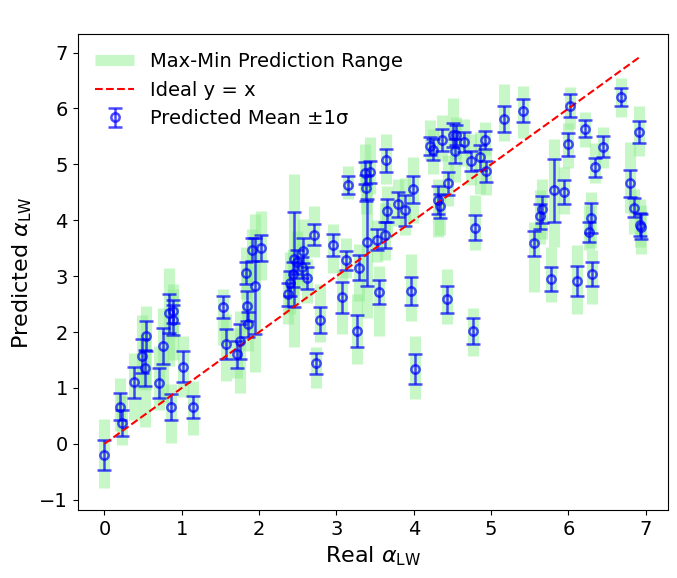

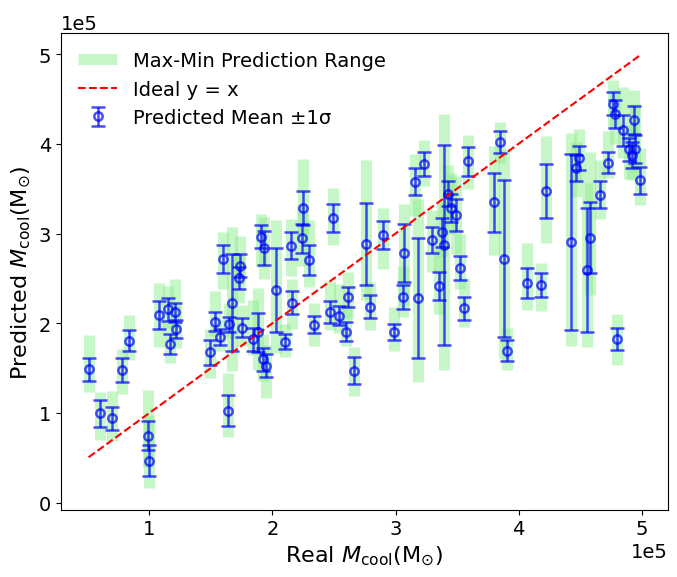

In [105]:
# ====================== 新代码块：四张独立图（Max-Min errorbar 实心中心 + 7bin 1σ色带） ======================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 设置学术风格
plt.rcParams['font.size'] = 14
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['xtick.labelsize'] = 14
plt.rcParams['ytick.labelsize'] = 14
plt.rcParams['legend.fontsize'] = 14
plt.rcParams['lines.linewidth'] = 1.5
plt.rcParams['lines.markersize'] = 6
plt.rcParams['text.usetex'] = False

# 读取数据（文件名完全保持原样）
df_k_nonoise   = pd.read_csv("modelD/k_LW_C.csv")    # 无噪音
df_m_nonoise   = pd.read_csv("modelD/M_cool_C.csv")  # 无噪音

# --------------------- 修改后的绘制函数 ---------------------
def plot_maxmin_with_sigma_band(df, real_col, min_col, max_col, mean_col, std_col,
                                         title, xlabel, ylabel, filename, use_sci=False):
    df_valid = df.dropna(subset=[min_col, max_col])
    
    if len(df_valid) == 0:
        print(f"警告：{filename} 无有效数据")
        return
    
    real = df_valid[real_col].values
    pred_min = df_valid[min_col].values
    pred_max = df_valid[max_col].values
    
    # 预测均值（若无则取中点）
    if mean_col in df_valid.columns and not df_valid[mean_col].isna().all():
        pred_mean = df_valid[mean_col].values
    else:
        pred_mean = (pred_min + pred_max) / 2
    
    # 预测标准差（若无则为0）
    if std_col in df_valid.columns and not df_valid[std_col].isna().all():
        pred_std = df_valid[std_col].values
    else:
        pred_std = np.zeros_like(pred_min)
    
    # 为了填充Max-Min范围，需要对点按real值排序
    sort_idx = np.argsort(real)
    real_sorted = real[sort_idx]
    min_sorted = pred_min[sort_idx]
    max_sorted = pred_max[sort_idx]
    
    # 创建图片
    fig, ax = plt.subplots(figsize=(7, 6))
    
    # === Max-Min 预测范围色带（不分bin，直接填充所有点的min到max）===
    ax.vlines(real_sorted, min_sorted, max_sorted,
                    color='lightgreen', alpha=0.5,linewidth=8,
                    label='Max-Min Prediction Range')
    
    # === errorbar 显示 ±1σ（中心为均值，实心圆点）===
    ax.errorbar(real, pred_mean, yerr=pred_std,
                fmt='o', color='blue', capsize=5, markersize=6,
                markerfacecolor='none', markeredgewidth=1.8, elinewidth=1.8, alpha=0.7,
                label='Predicted Mean ±1σ')
    
    # 理想线 y = x
    overall_min = real.min()
    overall_max = real.max()
    ax.plot([overall_min, overall_max], [overall_min, overall_max],
            'r--', lw=1.5, label='Ideal y = x')
    
    ax.set_xlabel(xlabel, fontsize=16)
    ax.set_ylabel(ylabel, fontsize=16)
    ax.set_title(title)
    if use_sci:
        ax.ticklabel_format(style='sci', axis='both', scilimits=(0,0))
    ax.legend(frameon=False, fontsize=14)
    
    plt.tight_layout()
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.show()

# --------------------- 绘制四张独立图 ---------------------

# 2. k_LW 无噪音
plot_maxmin_with_sigma_band(
    df_k_nonoise,
    real_col="k_LW_real",
    min_col="k_LW_pred_min",
    max_col="k_LW_pred_max",
    mean_col="k_LW_pred_mean",
    std_col="k_LW_pred_std",
    title=" ",
    xlabel="Real $\\alpha_{\\mathrm{LW}}$",
    ylabel="Predicted $\\alpha_{\\mathrm{LW}}$",
    filename="modelD/alphaLW_CaseC.pdf"
)

# 4. M_cool 无噪音
plot_maxmin_with_sigma_band(
    df_m_nonoise,
    real_col="M_cool_real",
    min_col="M_cool_pred_min",
    max_col="M_cool_pred_max",
    mean_col="M_cool_pred_mean",
    std_col="M_cool_pred_std",
    title=" ",
    xlabel="Real $M_{\\mathrm{cool}}(\\mathrm{{M_{{\\odot}}}})$",
    ylabel="Predicted $M_{\\mathrm{cool}}(\\mathrm{{M_{{\\odot}}}})$",
    filename="modelD/Mcool_CaseC.pdf",
    use_sci=True
)


选中的样本组：
真实 k_LW = 3.5500
真实 M_cool = 1.6500e+05 M_⊙
该组样本数量：36


/tmp/ipykernel_76623/3718277657.py:156: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.91, 1])


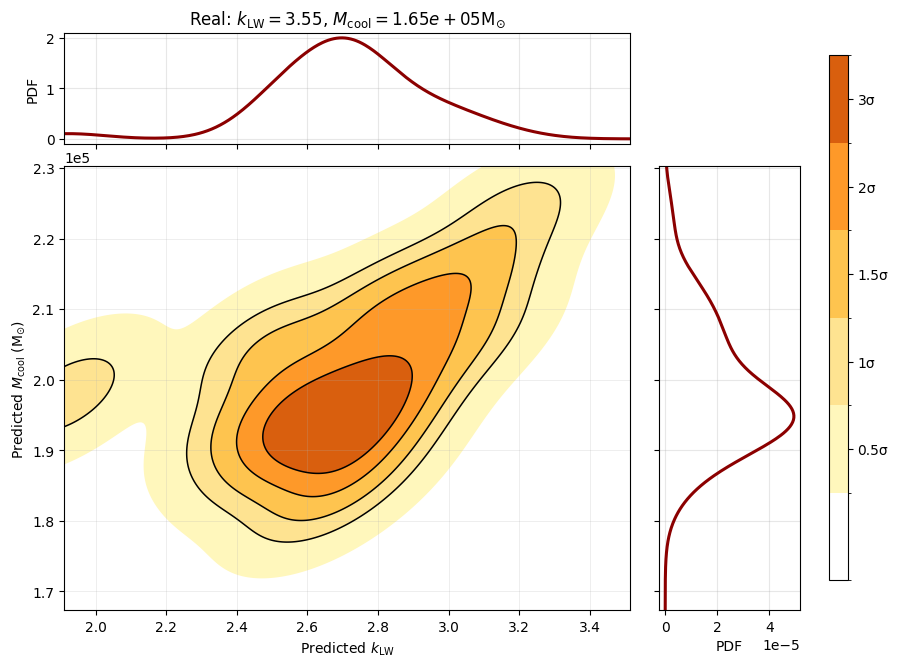


预测统计：
k_LW   = 2.712775 ± 0.216401
M_cool = 1.98794281e+05 ± 8.48711426e+03


In [68]:
# ====================== 最终方案：σ 阶梯纯色填充（地形图风格） ======================

from scipy.stats import gaussian_kde
import matplotlib.gridspec as gridspec
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import ListedColormap, BoundaryNorm

# ==================== 样本选择（保持不变） ====================
tol = 1e-6
trues_rounded = np.round(trues, decimals=8)
unique_combinations = np.unique(trues_rounded, axis=0)
unique_combinations = unique_combinations[np.lexsort(
    (unique_combinations[:, 1], unique_combinations[:, 0]))
]

selected_real_pair = unique_combinations[50]
print(f"\n选中的样本组：")
print(f"真实 k_LW = {selected_real_pair[0]:.4f}")
print(f"真实 M_cool = {selected_real_pair[1]:.4e} M_⊙")

mask = np.all(np.isclose(trues, selected_real_pair, atol=tol), axis=1)
selected_predictions = predictions[mask]
sample_count = len(selected_predictions)
print(f"该组样本数量：{sample_count}")

pred_klw = selected_predictions[:, 0]
pred_mcool = selected_predictions[:, 1]

# ==================== 画布布局 ====================
fig = plt.figure(figsize=(9.5, 7.5))
gs = gridspec.GridSpec(
    2, 2, width_ratios=[4, 1], height_ratios=[1, 4],
    wspace=0.08, hspace=0.08
)

ax_main = fig.add_subplot(gs[1, 0])
ax_top = fig.add_subplot(gs[0, 0], sharex=ax_main)
ax_right = fig.add_subplot(gs[1, 1], sharey=ax_main)

# ==================== 视野范围（完整 3.5σ） ====================
mean_klw, std_klw = np.mean(pred_klw), np.std(pred_klw)
mean_mcool, std_mcool = np.mean(pred_mcool), np.std(pred_mcool)

pad_sigma = 3.5
xmin = mean_klw - pad_sigma * std_klw
xmax = mean_klw + pad_sigma * std_klw
ymin = mean_mcool - pad_sigma * std_mcool
ymax = mean_mcool + pad_sigma * std_mcool

margin_x = 0.03 * (xmax - xmin)
margin_y = 0.03 * (ymax - ymin)
xmin -= margin_x
xmax += margin_x
ymin -= margin_y
ymax += margin_y

ax_main.set_xlim(xmin, xmax)
ax_main.set_ylim(ymin, ymax)

# ==================== 2D KDE ====================
kde = gaussian_kde(np.vstack([pred_klw, pred_mcool]))
X, Y = np.mgrid[xmin:xmax:400j, ymin:ymax:400j]
positions = np.vstack([X.ravel(), Y.ravel()])
Z = np.reshape(kde(positions).T, X.shape)

# ==================== σ 等概率区域计算（核心） ====================
Z_flat = Z.flatten()
idx = np.argsort(Z_flat)[::-1]
Z_sorted = Z_flat[idx]

cdf = np.cumsum(Z_sorted)
cdf /= cdf[-1]

sigma_probs = [0.393, 0.6827, 0.866, 0.9545, 0.9973]
pdf_levels = [Z_sorted[np.searchsorted(cdf, p)] for p in sigma_probs]

levels = [0.0] + sorted(pdf_levels) + [Z.max()]

# ==================== 离散纯色（地形图风格） ====================
sigma_colors = [
    "#ffffff",  # <0.5σ（背景）
    "#fff7bc",  # 0.5σ
    "#fee391",  # 1σ
    "#fec44f",  # 1.5σ
    "#fe9929",  # 2σ
    "#d95f0e",  # 3σ（核心）
]


cmap = ListedColormap(sigma_colors)
norm = BoundaryNorm(levels, cmap.N)

# ==================== 主图：σ 阶梯填色 ====================
cf = ax_main.contourf(
    X, Y, Z,
    levels=levels,
    cmap=cmap,
    norm=norm,
    antialiased=True
)

# σ 边界线（可选但强烈推荐）
ax_main.contour(
    X, Y, Z,
    levels=levels[2:-1],
    colors='k',
    linewidths=1.1
)

# ==================== 真实值 ====================
ax_main.axvline(selected_real_pair[0], color='red', ls='--', lw=1.8)
ax_main.axhline(selected_real_pair[1], color='red', ls='--', lw=1.8)

ax_main.set_xlabel('Predicted $k_{\\mathrm{LW}}$')
ax_main.set_ylabel('Predicted $M_{\\mathrm{cool}}$ ($\\mathrm{{M_{{\\odot}}}}$)')
ax_main.ticklabel_format(style='sci', axis='y', scilimits=(0, 0))
ax_main.grid(True, alpha=0.3, lw=0.5)

# ==================== 上方 1D KDE ====================
kde_klw = gaussian_kde(pred_klw)
x_klw = np.linspace(xmin, xmax, 400)
ax_top.plot(x_klw, kde_klw(x_klw), color='darkred', lw=2.2)
ax_top.axvline(selected_real_pair[0], color='red', ls='--', lw=1.8)
ax_top.set_ylabel('PDF')
ax_top.set_title(
    f'Real: $k_{{\\mathrm{{LW}}}}={selected_real_pair[0]:.2f}$, '
    f'$M_{{\\mathrm{{cool}}}}={selected_real_pair[1]:.2e} \\mathrm{{M_{{\\odot}}}}$'
)
ax_top.grid(True, alpha=0.3)
ax_top.tick_params(labelbottom=False)

# ==================== 右侧 1D KDE ====================
kde_mcool = gaussian_kde(pred_mcool)
y_mcool = np.linspace(ymin, ymax, 400)
ax_right.plot(kde_mcool(y_mcool), y_mcool, color='darkred', lw=2.2)
ax_right.axhline(selected_real_pair[1], color='red', ls='--', lw=1.8)
ax_right.set_xlabel('PDF')
ax_right.ticklabel_format(style='sci', axis='x', scilimits=(0, 0))
ax_right.tick_params(labelleft=False)
ax_right.grid(True, alpha=0.3)

# ==================== 颜色条（σ 标注） ====================
cbar_ax = fig.add_axes([0.93, 0.15, 0.02, 0.7])
cbar = fig.colorbar(cf, cax=cbar_ax)
cbar.set_ticks([
    (levels[i] + levels[i+1]) / 2 for i in range(1, 6)
])

cbar.set_ticklabels([
    '0.5σ', '1σ', '1.5σ', '2σ', '3σ'
])

cbar.set_label(' ')

plt.tight_layout(rect=[0, 0, 0.91, 1])
plt.savefig('modelD/2d_prediction_density_C.png',
            dpi=300, bbox_inches='tight')
plt.show()

# ==================== 统计输出 ====================
print(f"\n预测统计：")
print(f"k_LW   = {mean_klw:.6f} ± {std_klw:.6f}")
print(f"M_cool = {mean_mcool:.8e} ± {std_mcool:.8e}")


-10.701185964767351
-5.7793890621136175
-12.81357432689351
-12.213810055492145
-16.94886134764851
-49.384733725338194
-40.26967404670525


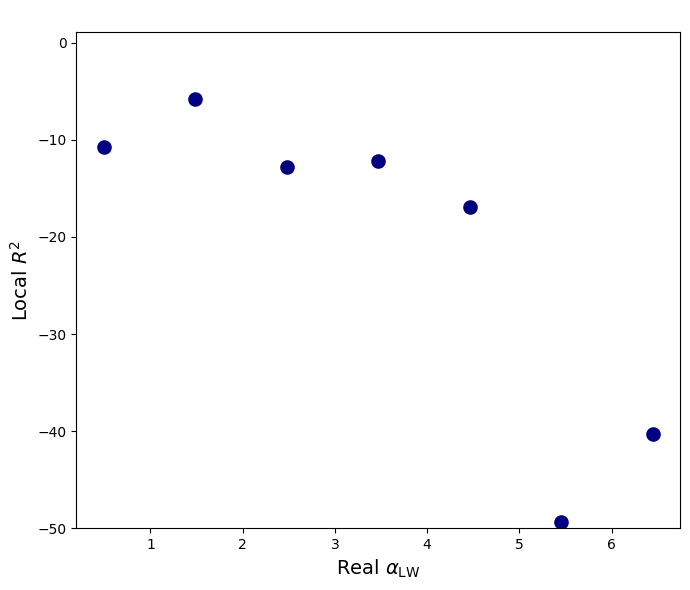

In [75]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 设置学术风格（与你原代码一致）
plt.rcParams['font.size'] = 10
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['axes.labelsize'] = 10
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10
plt.rcParams['legend.fontsize'] = 10
plt.rcParams['lines.linewidth'] = 1.5
plt.rcParams['lines.markersize'] = 8
plt.rcParams['text.usetex'] = False

# 读取包含 real 和 pred 的数据
df = pd.read_csv("modelD/k_LW_C.csv")  # 请确保列名正确

# 必需列名（根据你的数据调整）
real_col = "k_LW_real"          # 真实值列
pred_col = "k_LW_pred_mean"     # 预测均值列（推荐用 mean，如果没有可用 (min+max)/2）

# 去掉缺失值
df_valid = df.dropna(subset=[real_col, pred_col]).copy()

if len(df_valid) == 0:
    raise ValueError("有效数据为空，请检查列名或数据文件")

real = df_valid[real_col].values
pred = df_valid[pred_col].values

# --------------------- 计算分 bin 的局部 R² ---------------------
nbins = 7  # 可调整 bin 数量

overall_min = real.min()
overall_max = real.max()
bin_edges = np.linspace(overall_min, overall_max, nbins + 1)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

r2_per_bin = np.full(nbins, np.nan)

for i in range(nbins):
    mask = (real >= bin_edges[i]) & (real < bin_edges[i+1])
    if np.sum(mask) >= 2:  # 至少 2 个样本才能计算 R²
        y_true_bin = real[mask]
        y_pred_bin = pred[mask]
        
        ss_res = np.sum((y_true_bin - y_pred_bin) ** 2)
        ss_tot = np.sum((y_true_bin - np.mean(y_true_bin)) ** 2)
        r2 = 1 - ss_res / ss_tot if ss_tot > 0 else np.nan
        r2_per_bin[i] = r2
    else:
        r2_per_bin[i] = np.nan
    print(r2_per_bin[i])
# --------------------- 绘图 ---------------------
fig, ax = plt.subplots(figsize=(7, 6))

# 实心圆点标记每个 bin 的 R² 值
ax.plot(bin_centers, r2_per_bin, 'o', color='navy', markerfacecolor='navy',
        markersize=9, markeredgewidth=1.5, label='Local $R²$')

ax.set_xlabel("Real $\\alpha_{\\mathrm{LW}}$", fontsize=14)
ax.set_ylabel("Local $R^2$", fontsize=14)
ax.set_title(" ")  # 论文插图通常留空，由 caption 说明
ax.set_ylim(-50, 1.05)  # 留出空间显示负值（如果有）

plt.tight_layout()
plt.savefig("modelD/local_R2LW_vs_real_C.pdf", dpi=300, bbox_inches='tight')
# plt.savefig("local_R2_vs_real_modelB.png", dpi=300, bbox_inches='tight')
plt.show()

Bin 1 [0.000, 0.991): smoothL1 = 0.7761, 样本数 = 13
Bin 2 [0.991, 1.983): smoothL1 = 0.5646, 样本数 = 11
Bin 3 [1.983, 2.974): smoothL1 = 0.7032, 样本数 = 13
Bin 4 [2.974, 3.966): smoothL1 = 0.7042, 样本数 = 17
Bin 5 [3.966, 4.957): smoothL1 = 0.8418, 样本数 = 19
Bin 6 [4.957, 5.949): smoothL1 = 1.4143, 样本数 = 8
Bin 7 [5.949, 6.940): smoothL1 = 1.7031, 样本数 = 14


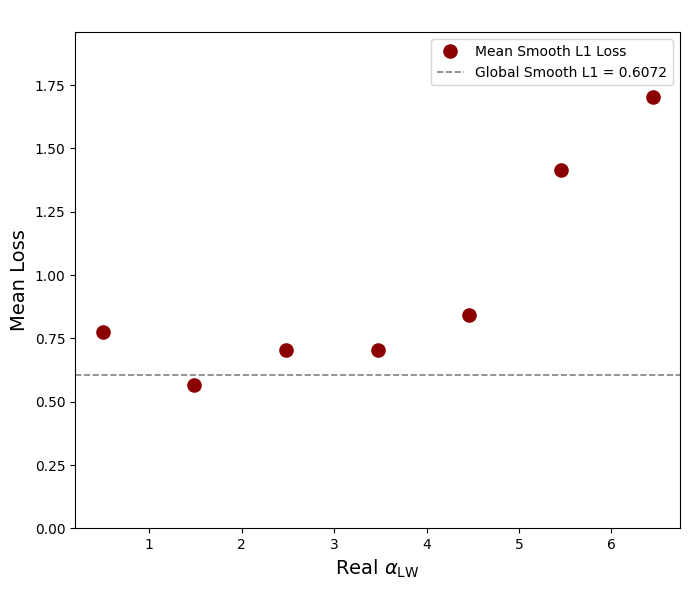

In [76]:

# --------------------- 保持与你原代码一致的学术风格 ---------------------
plt.rcParams['font.size'] = 10
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['axes.labelsize'] = 10
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10
plt.rcParams['legend.fontsize'] = 10
plt.rcParams['lines.linewidth'] = 1.5
plt.rcParams['lines.markersize'] = 8
plt.rcParams['text.usetex'] = False

# 读取数据
df = pd.read_csv("modelD/k_LW_C.csv")

# 必需列名
real_col = "k_LW_real"
pred_col = "k_LW_pred_mean"   # 用 mean 作为代表预测值

# 去掉缺失值
df_valid = df.dropna(subset=[real_col, pred_col]).copy()

if len(df_valid) == 0:
    raise ValueError("有效数据为空，请检查列名或数据文件")

real = df_valid[real_col].values
pred = df_valid[pred_col].values

# --------------------- 计算分 bin 的 Smooth L1 Loss ---------------------
nbins = 7  # 与你 R² 代码保持一致，可调整

overall_min = real.min()
overall_max = real.max()
bin_edges = np.linspace(overall_min, overall_max, nbins + 1)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

smooth_l1_per_bin = np.full(nbins, np.nan)

def smooth_l1_loss(y_true, y_pred, beta=0.1):
    """Smooth L1 Loss (Huber-like)"""
    diff = np.abs(y_true - y_pred)
    loss = np.where(diff < beta,
                    0.5 * (diff ** 2) / beta,
                    diff - 0.5 * beta)
    return np.mean(loss)  # 返回 bin 内的平均 loss

for i in range(nbins):
    mask = (real >= bin_edges[i]) & (real < bin_edges[i+1])
    if np.sum(mask) >= 1:  # loss 只要有 1 个样本就能算（但建议 ≥5 才靠谱）
        y_true_bin = real[mask]
        y_pred_bin = pred[mask]
        
        loss_mean = smooth_l1_loss(y_true_bin, y_pred_bin, beta=0.1)
        smooth_l1_per_bin[i] = loss_mean
    else:
        smooth_l1_per_bin[i] = np.nan
    
    # 顺便打印看看每个 bin 的 loss 和样本量
    print(f"Bin {i+1} [{bin_edges[i]:.3f}, {bin_edges[i+1]:.3f}): "
          f"smoothL1 = {smooth_l1_per_bin[i]:.4f}, 样本数 = {np.sum(mask)}")

# --------------------- 绘图 ---------------------
fig, ax = plt.subplots(figsize=(7, 6))

# 用实心圆点画每个 bin 的平均 Smooth L1 Loss
ax.plot(bin_centers, smooth_l1_per_bin, 'o', color='darkred', markerfacecolor='darkred',
        markersize=9, markeredgewidth=1.5, label='Mean Smooth L1 Loss')

ax.set_xlabel("Real $\\alpha_{\\mathrm{LW}}$", fontsize=14)
ax.set_ylabel("Mean Loss", fontsize=14)
ax.set_title(" ")  # 论文图通常标题留空，放 caption
# 根据你的数据范围调整 y 轴（loss 通常不会太大，可视情况改）
ax.set_ylim(0, np.nanmax(smooth_l1_per_bin) * 1.15 if not np.all(np.isnan(smooth_l1_per_bin)) else 1)

# 可选：加一条水平参考线（例如全局平均 loss）
global_loss = smooth_l1_loss(real, pred, beta=1.0)
ax.axhline(global_loss, color='gray', linestyle='--', linewidth=1.2,
           label=f'Global Smooth L1 = {global_loss:.4f}')

ax.legend(frameon=True, fontsize=10)

plt.tight_layout()
plt.savefig("modelD/local_smoothL1_vs_real_C.pdf", dpi=300, bbox_inches='tight')
# plt.savefig("local_smoothL1_vs_real_C.png", dpi=300, bbox_inches='tight')
plt.show()

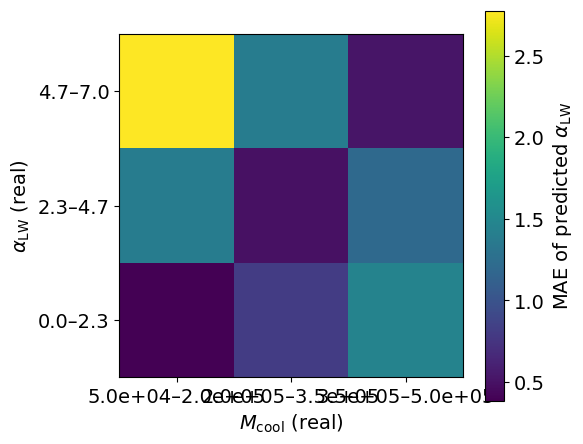

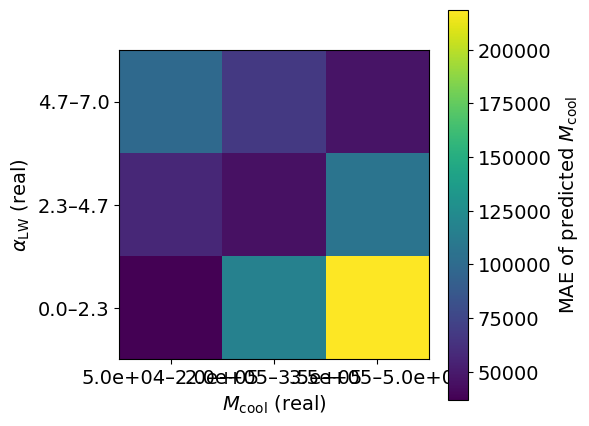

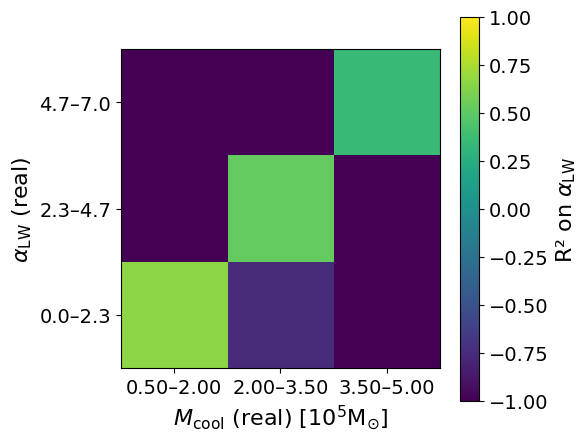

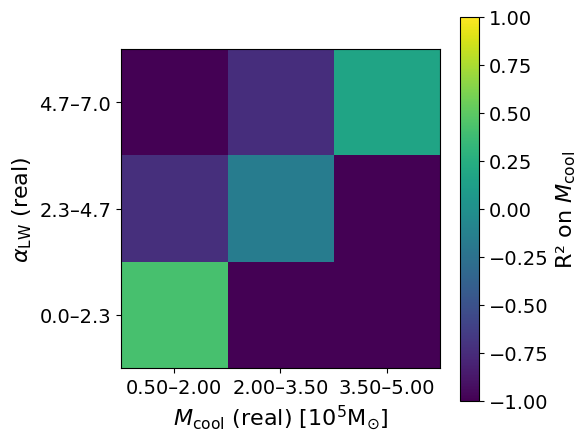

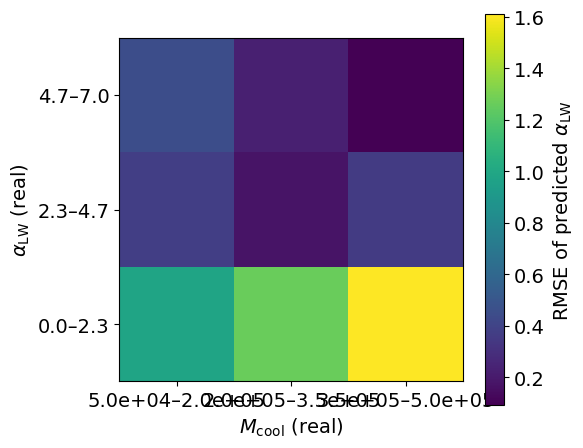

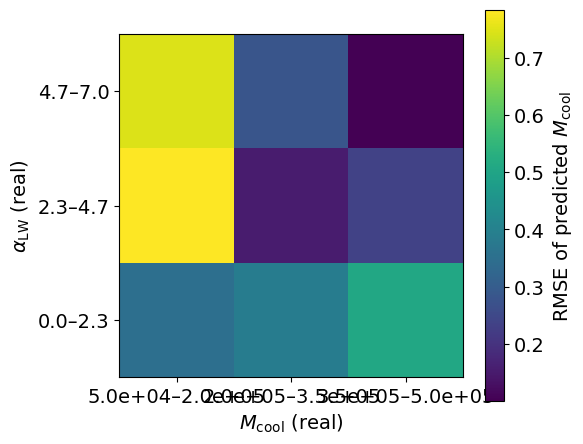

In [109]:
# klw 和 mcool 的分箱边界
klw_bins = np.linspace(0.0, 7.0, 4)          # 3 bins
mcool_bins = np.linspace(5e4, 5e5, 4)        # 3 bins

def mae_1d(y_true, y_pred):
    return np.sqrt(np.mean((y_true - y_pred) ** 2))

def r2_score_1d(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    return 1.0 - ss_res / ss_tot if ss_tot > 0 else np.nan

def rmse_1d(y_true, y_pred, klw_min=0.1):
    """
    Relative RMSE for klw, excluding samples with klw < klw_min
    """
    mask = y_true >= klw_min
    if np.sum(mask) < 2:
        return np.nan
    
    frac_err2 = ((y_pred[mask] - y_true[mask]) / y_true[mask]) ** 2
    return np.sqrt(np.mean(frac_err2))

mse_klw_grid = np.full((3, 3), np.nan)
mse_mcool_grid = np.full((3, 3), np.nan)
r2_klw_grid = np.full((3, 3), np.nan)
r2_mcool_grid = np.full((3, 3), np.nan)
rmse_klw_grid = np.full((3, 3), np.nan)
rmse_mcool_grid = np.full((3, 3), np.nan)
count_grid = np.zeros((3, 3), dtype=int)

for i in range(3):      # klw bins
    for j in range(3):  # mcool bins
        
        klw_mask = (trues[:, 0] >= klw_bins[i]) & (trues[:, 0] < klw_bins[i+1])
        mcool_mask = (trues[:, 1] >= mcool_bins[j]) & (trues[:, 1] < mcool_bins[j+1])
        mask = klw_mask & mcool_mask
        
        if np.sum(mask) < 2:
            continue
        
        y_true_bin = trues[mask]
        y_pred_bin = predictions[mask]
        
        # klw
        mse_klw_grid[i, j] = mae_1d(
            y_true_bin[:, 0], y_pred_bin[:, 0]
        )
        r2_klw_grid[i, j] = r2_score_1d(
            y_true_bin[:, 0], y_pred_bin[:, 0]
        )
        rmse_klw_grid[i, j] = rmse_1d(
            y_true_bin[:, 0], y_pred_bin[:, 0], klw_min=0.1
        )
        
        # mcool
        mse_mcool_grid[i, j] = mae_1d(
            y_true_bin[:, 1], y_pred_bin[:, 1]
        )
        r2_mcool_grid[i, j] = r2_score_1d(
            y_true_bin[:, 1], y_pred_bin[:, 1]
        )
        rmse_mcool_grid[i, j] = rmse_1d(
            y_true_bin[:, 1], y_pred_bin[:, 1]
        )
        
        count_grid[i, j] = np.sum(mask)
mcool_bins_scaled = mcool_bins / 1e5

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(mse_klw_grid, origin='lower')

ax.set_xticks(range(3))
ax.set_yticks(range(3))
ax.set_xticklabels([f'{mcool_bins[i]:.1e}–{mcool_bins[i+1]:.1e}' for i in range(3)])
ax.set_yticklabels([f'{klw_bins[i]:.1f}–{klw_bins[i+1]:.1f}' for i in range(3)])

ax.set_xlabel('$M_{\\mathrm{cool}}$ (real)')
ax.set_ylabel('$\\alpha_{\\mathrm{LW}}$ (real)')
ax.set_title(' ')

cbar = plt.colorbar(im, ax=ax)
cbar.set_label('MAE of predicted $\\alpha_{\\mathrm{LW}}$')

plt.tight_layout()
plt.savefig("modelD/local_MAELW_vs_real_C.pdf", dpi=300, bbox_inches='tight')
plt.show()

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(mse_mcool_grid, origin='lower')

ax.set_xticks(range(3))
ax.set_yticks(range(3))
ax.set_xticklabels([f'{mcool_bins[i]:.1e}–{mcool_bins[i+1]:.1e}' for i in range(3)])
ax.set_yticklabels([f'{klw_bins[i]:.1f}–{klw_bins[i+1]:.1f}' for i in range(3)])

ax.set_xlabel('$M_{\\mathrm{cool}}$ (real)')
ax.set_ylabel('$\\alpha_{\\mathrm{LW}}$ (real)')
ax.set_title(' ')

cbar = plt.colorbar(im, ax=ax)
cbar.set_label('MAE of predicted $M_{\\mathrm{cool}}$')

plt.tight_layout()
plt.savefig("modelD/local_MAEmcool_vs_real_C.pdf", dpi=300, bbox_inches='tight')
plt.show()

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(r2_klw_grid, origin='lower', vmin=-1, vmax=1)

ax.set_xticks(range(3))
ax.set_yticks(range(3))
ax.set_xticklabels([f'{mcool_bins_scaled[i]:.2f}–{mcool_bins_scaled[i+1]:.2f}' for i in range(3)])
ax.set_yticklabels([f'{klw_bins[i]:.1f}–{klw_bins[i+1]:.1f}' for i in range(3)])

ax.set_xlabel('$M_{\\mathrm{cool}}$ (real) $[10^5 \\mathrm{M_{\\odot}}]$', fontsize=16)
ax.set_ylabel('$\\alpha_{\\mathrm{LW}}$ (real)', fontsize=16)
ax.set_title(' ')

cbar = plt.colorbar(im, ax=ax)
cbar.set_label('R² on $\\alpha_{\\mathrm{LW}}$', fontsize=16)
plt.tight_layout()
plt.savefig("modelD/local_R2LW_caseC.pdf", dpi=300, bbox_inches='tight')
plt.show()

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(r2_mcool_grid, origin='lower', vmin=-1, vmax=1)

ax.set_xticks(range(3))
ax.set_yticks(range(3))
ax.set_xticklabels([f'{mcool_bins_scaled[i]:.2f}–{mcool_bins_scaled[i+1]:.2f}' for i in range(3)])
ax.set_yticklabels([f'{klw_bins[i]:.1f}–{klw_bins[i+1]:.1f}' for i in range(3)])
ax.set_xlabel('$M_{\\mathrm{cool}}$ (real) $[10^5 \\mathrm{M_{\\odot}}]$', fontsize=16)
ax.set_ylabel('$\\alpha_{\\mathrm{LW}}$ (real)', fontsize=16)
ax.set_title(' ')

cbar = plt.colorbar(im, ax=ax)
cbar.set_label('R² on $M_{\\mathrm{cool}}$', fontsize=16)
plt.tight_layout()
plt.savefig("modelD/local_R2mcool_caseC.pdf", dpi=300, bbox_inches='tight')
plt.show()

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(rmse_klw_grid, origin='lower')

ax.set_xticks(range(3))
ax.set_yticks(range(3))
ax.set_xticklabels([f'{mcool_bins[i]:.1e}–{mcool_bins[i+1]:.1e}' for i in range(3)])
ax.set_yticklabels([f'{klw_bins[i]:.1f}–{klw_bins[i+1]:.1f}' for i in range(3)])

ax.set_xlabel('$M_{\\mathrm{cool}}$ (real)')
ax.set_ylabel('$\\alpha_{\\mathrm{LW}}$ (real)')
ax.set_title(' ')

cbar = plt.colorbar(im, ax=ax)
cbar.set_label('RMSE of predicted $\\alpha_{\\mathrm{LW}}$')

plt.tight_layout()
plt.savefig("modelD/local_RMSELW_vs_real_C.pdf", dpi=300, bbox_inches='tight')
plt.show()

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(rmse_mcool_grid, origin='lower')

ax.set_xticks(range(3))
ax.set_yticks(range(3))
ax.set_xticklabels([f'{mcool_bins[i]:.1e}–{mcool_bins[i+1]:.1e}' for i in range(3)])
ax.set_yticklabels([f'{klw_bins[i]:.1f}–{klw_bins[i+1]:.1f}' for i in range(3)])

ax.set_xlabel('$M_{\\mathrm{cool}}$ (real)', fontsize=14)
ax.set_ylabel('$\\alpha_{\\mathrm{LW}}$ (real)', fontsize=14)
ax.set_title(' ')

cbar = plt.colorbar(im, ax=ax)
cbar.set_label('RMSE of predicted $M_{\\mathrm{cool}}$')

plt.tight_layout()
plt.savefig("modelD/local_RMSEmcool_vs_real_C.pdf", dpi=300, bbox_inches='tight')
plt.show()

In [91]:
print("=" * 80)
print("R^2 values in each (klw, mcool) bin")
print("=" * 80)

for i in range(4):      # klw bins
    for j in range(4):  # mcool bins
        
        klw_range = f"[{klw_bins[i]:.2f}, {klw_bins[i+1]:.2f})"
        mcool_range = f"[{mcool_bins[j]:.2e}, {mcool_bins[j+1]:.2e})"
        N = count_grid[i, j]
        
        if N < 2:
            print(f"klw {klw_range}, mcool {mcool_range} : "
                  f"N = {N}  --> insufficient samples")
            continue
        
        print(
            f"klw {klw_range}, mcool {mcool_range} : "
            f"N = {N:4d} | "
            f"R^2(klw) = {r2_klw_grid[i, j]: .4f} | "
            f"R^2(mcool) = {r2_mcool_grid[i, j]: .4f}"
        )

print("=" * 80)

print("=" * 80)
print("RMSE values in each (klw, mcool) bin")
print("=" * 80)

for i in range(4):      # klw bins
    for j in range(4):  # mcool bins
        
        klw_range = f"[{klw_bins[i]:.2f}, {klw_bins[i+1]:.2f})"
        mcool_range = f"[{mcool_bins[j]:.2e}, {mcool_bins[j+1]:.2e})"
        N = count_grid[i, j]
        
        if N < 2:
            print(f"klw {klw_range}, mcool {mcool_range} : "
                  f"N = {N}  --> insufficient samples")
            continue
        
        print(
            f"klw {klw_range}, mcool {mcool_range} : "
            f"N = {N:4d} | "
            f"RMSE(klw) = {rmse_klw_grid[i, j]: .4f} | "
            f"RMSE(mcool) = {rmse_mcool_grid[i, j]: .4f}"
        )

print("=" * 80)


R^2 values in each (klw, mcool) bin
klw [0.00, 1.75), mcool [5.00e+04, 1.62e+05) : N =  180 | R^2(klw) =  0.6717 | R^2(mcool) = -0.4621
klw [0.00, 1.75), mcool [1.62e+05, 2.75e+05) : N =  180 | R^2(klw) = -0.2070 | R^2(mcool) = -2.7333
klw [0.00, 1.75), mcool [2.75e+05, 3.88e+05) : N =  108 | R^2(klw) = -4.0003 | R^2(mcool) = -76.5964
klw [0.00, 1.75), mcool [3.88e+05, 5.00e+05) : N =  180 | R^2(klw) = -63.2937 | R^2(mcool) = -46.1639
klw [1.75, 3.50), mcool [5.00e+04, 1.62e+05) : N =  108 | R^2(klw) = -20.3583 | R^2(mcool) = -2.0578
klw [1.75, 3.50), mcool [1.62e+05, 2.75e+05) : N =  432 | R^2(klw) =  0.4404 | R^2(mcool) = -0.0810
klw [1.75, 3.50), mcool [2.75e+05, 3.88e+05) : N =  288 | R^2(klw) = -3.4917 | R^2(mcool) = -5.1506
klw [1.75, 3.50), mcool [3.88e+05, 5.00e+05) : N =  288 | R^2(klw) = -4.5335 | R^2(mcool) = -48.2629
klw [3.50, 5.25), mcool [5.00e+04, 1.62e+05) : N =  144 | R^2(klw) = -45.2339 | R^2(mcool) = -3.5149
klw [3.50, 5.25), mcool [1.62e+05, 2.75e+05) : N =   72 | 

crossvalidation

In [58]:

from torch.utils.data import Dataset, DataLoader, SubsetRandomSampler
from sklearn.model_selection import KFold

train_data = torch.load('modelD/processed_tensors/caseC/train_data.pt')
valid_data = torch.load('modelD/processed_tensors/caseC/valid_data.pt')
train_images = train_data['images']
train_labels = train_data['labels']
valid_images = valid_data['images']
valid_labels = valid_data['labels']
# 合并成完整数据集
full_images = torch.cat([train_images, valid_images])
full_labels = torch.cat([train_labels, valid_labels])

print(f"Full dataset size: {len(full_images)}, {len(full_labels)}")  # 比如 1000 张

Full dataset size: 32400, 32400


In [59]:
# ------------------- 1. 自定义 Dataset -------------------
class MergedDataset(Dataset):
    def __init__(self, images, labels):
        """
        images: torch.Tensor of shape (N, C, H, W)
        labels: torch.Tensor of shape (N, 2)  # 两个回归目标
        """
        self.images = images
        self.labels = labels
        assert len(self.images) == len(self.labels), "Images and labels must have same length!"

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image = self.images[idx]   # 已经是 tensor，不需要 ToTensor
        label = self.labels[idx]   # shape (2,)
        return image, label

In [60]:
def load_and_merge(train_pt_path='train_data.pt', valid_pt_path='valid_data.pt'):
    print("Loading train and valid .pt files...")

    # 合并
    full_images = torch.cat([train_images, valid_images], dim=0)
    full_labels = torch.cat([train_labels, valid_labels], dim=0)

    print(f"Train images: {train_images.shape} → labels: {train_labels.shape}")
    print(f"Valid images: {valid_images.shape} → labels: {valid_labels.shape}")
    print(f"Full dataset: images {full_images.shape}, labels {full_labels.shape}")

    return MergedDataset(full_images, full_labels)

In [61]:
def r2_score(y_true, y_pred):
    ss_res = torch.sum((y_true - y_pred) ** 2)
    ss_tot = torch.sum((y_true - torch.mean(y_true)) ** 2)
    return 1 - (ss_res / ss_tot)

def train_model_cv(
    model, train_loader, valid_loader,
    criterion, mae_metric, optimizer, scheduler,
    epochs=200, patience=30,
    w_klw=1.0, w_mcool=1.0,
    device=None,
    fold=None,                    # 新增：当前是第几个 fold
    save_dir='cv_models_modelD'   # 新增：统一保存目录
):
    """
    CV 专用的训练函数，每个 fold 独立保存模型和历史记录
    """
    if device is None:
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Using device: {device}")
    
    model = model.to(device)
    
    os.makedirs(save_dir, exist_ok=True)
    
    # 每个 fold 独立的路径
    if fold is not None:
        model_path = os.path.join(save_dir, f'best_model_fold{fold}.pt')
        csv_path = os.path.join(save_dir, f'training_history_fold{fold}.csv')
    else:
        model_path = os.path.join(save_dir, 'best_model_caseC_crossvalid.pt')
        csv_path = os.path.join(save_dir, 'training_history_caseC_crossvalid.csv')

    best_valid_loss = float('inf')
    early_stop_counter = 0

    # 历史记录
    history = {
        'epoch': [],
        'train_loss': [],
        'train_mae_klw': [], 'train_mae_mcool': [],
        'valid_loss': [],
        'valid_mae_klw': [], 'valid_mae_mcool': [],
        'valid_r2_klw': [], 'valid_r2_mcool': []
    }

    for epoch in range(epochs):
        # =================== Training ===================
        model.train()
        train_loss = 0.0
        train_mae_klw = 0.0
        train_mae_mcool = 0.0
        train_samples = 0

        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            
            optimizer.zero_grad()
            output = model(x)  # (B, 2)
            
            loss_klw = criterion(output[:, 0], y[:, 0]) * w_klw
            loss_mcool = criterion(output[:, 1], y[:, 1]) * w_mcool
            loss = loss_klw + loss_mcool
            
            loss.backward()
            optimizer.step()
            
            batch_size = x.size(0)
            train_loss += loss.item() * batch_size
            train_mae_klw += mae_metric(output[:, 0], y[:, 0]).item() * batch_size
            train_mae_mcool += mae_metric(output[:, 1], y[:, 1]).item() * batch_size
            train_samples += batch_size
        
        train_loss /= train_samples
        train_mae_klw /= train_samples
        train_mae_mcool /= train_samples

        # =================== Validation ===================
        model.eval()
        valid_loss = 0.0
        valid_mae_klw = 0.0
        valid_mae_mcool = 0.0
        valid_samples = 0
        all_preds = []
        all_trues = []
        
        with torch.no_grad():
            for x, y in valid_loader:
                x, y = x.to(device), y.to(device)
                output = model(x)
                
                loss_klw = criterion(output[:, 0], y[:, 0]) * w_klw
                loss_mcool = criterion(output[:, 1], y[:, 1]) * w_mcool
                loss = loss_klw + loss_mcool
                
                batch_size = x.size(0)
                valid_loss += loss.item() * batch_size
                valid_mae_klw += mae_metric(output[:, 0], y[:, 0]).item() * batch_size
                valid_mae_mcool += mae_metric(output[:, 1], y[:, 1]).item() * batch_size
                valid_samples += batch_size
                
                all_preds.append(output.cpu())
                all_trues.append(y.cpu())
        
        valid_loss /= valid_samples
        valid_mae_klw /= valid_samples
        valid_mae_mcool /= valid_samples
        
        all_pred = torch.cat(all_preds, dim=0)
        all_true = torch.cat(all_trues, dim=0)
        valid_r2_klw = r2_score(all_true[:, 0], all_pred[:, 0]).item()
        valid_r2_mcool = r2_score(all_true[:, 1], all_pred[:, 1]).item()

        # =================== Scheduler Step ===================
        scheduler.step(valid_loss)

        # =================== Record History ===================
        history['epoch'].append(epoch + 1)
        history['train_loss'].append(train_loss)
        history['train_mae_klw'].append(train_mae_klw)
        history['train_mae_mcool'].append(train_mae_mcool)
        history['valid_loss'].append(valid_loss)
        history['valid_mae_klw'].append(valid_mae_klw)
        history['valid_mae_mcool'].append(valid_mae_mcool)
        history['valid_r2_klw'].append(valid_r2_klw)
        history['valid_r2_mcool'].append(valid_r2_mcool)

        # =================== Print ===================
        fold_str = f"[Fold {fold}] " if fold is not None else ""
        print(f'{fold_str}Epoch {epoch+1:3d}/{epochs} | '
              f'Train Loss: {train_loss:.4f} | T-MAE klw: {train_mae_klw:.4f} | T-MAE mcool: {train_mae_mcool:.4f} | '
              f'Valid Loss: {valid_loss:.4f} | V-MAE klw: {valid_mae_klw:.4f} | V-MAE mcool: {valid_mae_mcool:.4f} | '
              f'V-R² klw: {valid_r2_klw:.4f} | V-R² mcool: {valid_r2_mcool:.4f}')

        # =================== Early Stopping & Save Best ===================
        if valid_loss < best_valid_loss:
            best_valid_loss = valid_loss
            torch.save(model.state_dict(), model_path)
            early_stop_counter = 0
            print(f"  → New best model saved! (Valid Loss: {best_valid_loss:.4f})")
        else:
            early_stop_counter += 1
            if early_stop_counter >= patience:
                print(f"\nEarly stopping triggered at epoch {epoch+1}")
                break

    # =================== Save History ===================
    df_history = pd.DataFrame(history)
    df_history.to_csv(csv_path, index=False)
    print(f"Training history saved to: {csv_path}")

    # =================== Load Best Model ===================
    print(f"Loading best model weights from {model_path}...")
    model.load_state_dict(torch.load(model_path, map_location=device))

    return model, history

In [62]:
def run_cross_validation(
    model_class,
    full_dataset,
    k_folds=5,
    batch_size=32,
    epochs=200,
    patience=25,
    lr=0.001,
    weight_decay=1e-3,
    save_dir='modelD/cvmodelC'
):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    os.makedirs(save_dir, exist_ok=True)

    kf = KFold(n_splits=k_folds, shuffle=True, random_state=42)
    results = []

    for fold, (train_idx, val_idx) in enumerate(kf.split(np.arange(len(full_dataset)))):
        print(f"\n{'='*60}")
        print(f"Starting Fold {fold+1}/{k_folds}")
        print(f"{'='*60}")

        # Sampler
        train_sampler = SubsetRandomSampler(train_idx)
        val_sampler = SubsetRandomSampler(val_idx)

        train_loader = DataLoader(full_dataset, batch_size=batch_size, sampler=train_sampler)
        val_loader = DataLoader(full_dataset, batch_size=batch_size, sampler=val_sampler)

        # 新模型
        model = model_class().to(device)

        criterion = nn.MSELoss()
        mae_metric = MeanAbsoluteError().to(device)

        optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
        scheduler = optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode='min', factor=0.5, patience=10, min_lr=1e-6
        )

        model, history = train_model_cv(  
            model=model,
            train_loader=train_loader,
            valid_loader=val_loader,
            criterion=criterion,
            mae_metric=mae_metric,
            optimizer=optimizer,
            scheduler=scheduler,
            epochs=epochs,
            patience=patience,
            device=device,
            fold=fold,
            save_dir=save_dir
        )

        # 从 history 提取最佳指标（假设 history 有 'valid_mae_klw' 和 'valid_mae_mcool'）
        best_idx = np.argmin(history['valid_loss'])
        best_loss = history['valid_loss'][best_idx]
        best_mae_klw = history['valid_mae_klw'][best_idx]
        best_mae_mcool = history['valid_mae_mcool'][best_idx]

        results.append({
            'fold': fold + 1,
            'best_valid_loss': best_loss,
            'best_mae_klw': best_mae_klw,
            'best_mae_mcool': best_mae_mcool
        })

        print(f"Fold {fold+1} Best → Loss: {best_loss:.6f} | MAE α_LW: {best_mae_klw:.4f} | MAE M_cool: {best_mae_mcool:.4f}")

    # ------------------- CV 总结 -------------------
    df = pd.DataFrame(results)
    print("\n" + "="*60)
    print("CROSS VALIDATION SUMMARY")
    print("="*60)
    print(df)
    print(f"\nMAE α_LW:  {df['best_mae_klw'].mean():.4f} ± {df['best_mae_klw'].std():.4f}")
    print(f"MAE M_cool: {df['best_mae_mcool'].mean():.4f} ± {df['best_mae_mcool'].std():.4f}")
    print(f"Valid Loss: {df['best_valid_loss'].mean():.6f} ± {df['best_valid_loss'].std():.6f}")

    df.to_csv(os.path.join(save_dir, 'cv_results_summary.csv'), index=False)
    return df, results

In [63]:
if __name__ == "__main__":
    full_dataset = load_and_merge('train_data.pt', 'valid_data.pt')

    # 替换成你的模型类
    class YourModel(nn.Module):
        def __init__(self):
            super().__init__()
            # ... 你的模型结构
            pass
        def forward(self, x):
            # 返回 shape (B, 2) 或分别返回两个值
            pass

    df_cv = run_cross_validation(
        model_class=CNN,
        full_dataset=full_dataset,
        k_folds=5,
        batch_size=32,
        epochs=200,
        patience=25,
        lr=0.001,
        weight_decay=1e-3
    )

Loading train and valid .pt files...
Train images: torch.Size([28800, 1, 20, 40]) → labels: torch.Size([28800, 2])
Valid images: torch.Size([3600, 1, 20, 40]) → labels: torch.Size([3600, 2])
Full dataset: images torch.Size([32400, 1, 20, 40]), labels torch.Size([32400, 2])

Starting Fold 1/5
Using device: cuda
[Fold 0] Epoch   1/200 | Train Loss: 1.2686 | T-MAE klw: 0.6052 | T-MAE mcool: 0.6969 | Valid Loss: 1.1224 | V-MAE klw: 0.5704 | V-MAE mcool: 0.6557 | V-R² klw: 0.5053 | V-R² mcool: 0.3804
  → New best model saved! (Valid Loss: 1.1224)
[Fold 0] Epoch   2/200 | Train Loss: 1.1969 | T-MAE klw: 0.5983 | T-MAE mcool: 0.6808 | Valid Loss: 1.1619 | V-MAE klw: 0.5964 | V-MAE mcool: 0.6776 | V-R² klw: 0.4828 | V-R² mcool: 0.3636
[Fold 0] Epoch   3/200 | Train Loss: 1.1958 | T-MAE klw: 0.6000 | T-MAE mcool: 0.6789 | Valid Loss: 1.1127 | V-MAE klw: 0.5617 | V-MAE mcool: 0.6504 | V-R² klw: 0.5086 | V-R² mcool: 0.3868
  → New best model saved! (Valid Loss: 1.1127)
[Fold 0] Epoch   4/200 | Tr

成功读取 5 个 fold，最长训练 55 个 epoch


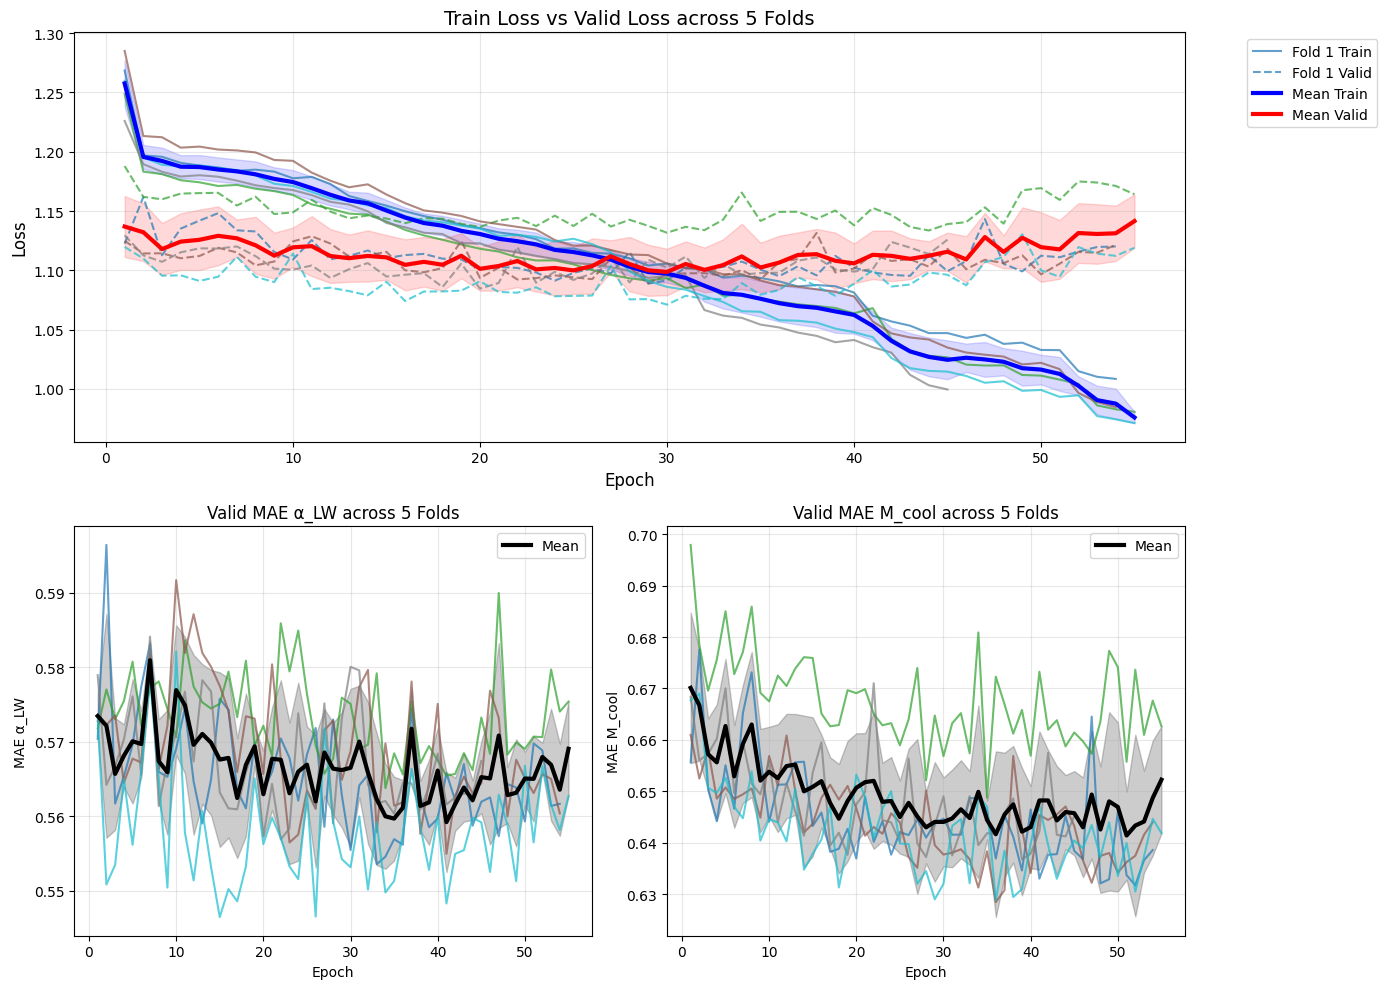

In [64]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

# ------------------- 参数设置 -------------------
save_dir = 'modelD/cvmodelC'  # 改成你的实际目录
folds = 5
colors = plt.cm.tab10(np.linspace(0, 1, folds))  # 更鲜艳的颜色，便于区分

# ------------------- 读取所有 fold 的历史 -------------------
histories = []
max_epochs = 0
for fold in range(folds):
    csv_path = os.path.join(save_dir, f'training_history_fold{fold}.csv')
    if not os.path.exists(csv_path):
        raise FileNotFoundError(f"找不到文件: {csv_path}")
    
    df = pd.read_csv(csv_path)
    histories.append(df)
    max_epochs = max(max_epochs, len(df))

print(f"成功读取 {folds} 个 fold，最长训练 {max_epochs} 个 epoch")

# ------------------- 对齐 epoch -------------------
valid_losses = np.full((folds, max_epochs), np.nan)
train_losses = np.full((folds, max_epochs), np.nan)
valid_mae_klw = np.full((folds, max_epochs), np.nan)
valid_mae_mcool = np.full((folds, max_epochs), np.nan)

for i, df in enumerate(histories):
    n = len(df)
    valid_losses[i, :n] = df['valid_loss'].values
    train_losses[i, :n] = df['train_loss'].values
    valid_mae_klw[i, :n] = df['valid_mae_klw'].values
    valid_mae_mcool[i, :n] = df['valid_mae_mcool'].values

epochs = np.arange(1, max_epochs + 1)

# ------------------- 绘图（1 大图 + 2 小图） -------------------
plt.figure(figsize=(14, 10))

# 1. Train Loss 和 Valid Loss 同图
plt.subplot(2, 2, (1, 2))  # 占前两格（横向大图）
# 画每个 fold 的两条线（train 实线，valid 虚线）
for i in range(folds):
    fold_epochs = epochs[:len(histories[i])]
    plt.plot(fold_epochs, histories[i]['train_loss'], 
             color=colors[i], linestyle='-', alpha=0.7, linewidth=1.5, label=f'Fold {i+1} Train' if i==0 else None)
    plt.plot(fold_epochs, histories[i]['valid_loss'], 
             color=colors[i], linestyle='--', alpha=0.7, linewidth=1.5, label=f'Fold {i+1} Valid' if i==0 else None)

# 均值曲线
mean_train = np.nanmean(train_losses, axis=0)
std_train = np.nanstd(train_losses, axis=0)
mean_valid = np.nanmean(valid_losses, axis=0)
std_valid = np.nanstd(valid_losses, axis=0)

plt.plot(epochs, mean_train, color='blue', linewidth=3, label='Mean Train')
plt.fill_between(epochs, mean_train - std_train, mean_train + std_train, color='blue', alpha=0.15)

plt.plot(epochs, mean_valid, color='red', linewidth=3, label='Mean Valid')
plt.fill_between(epochs, mean_valid - std_valid, mean_valid + std_valid, color='red', alpha=0.15)

plt.title('Train Loss vs Valid Loss across 5 Folds', fontsize=14)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
plt.grid(True, alpha=0.3)

# 2. Valid MAE α_LW
plt.subplot(2, 2, 3)
for i in range(folds):
    plt.plot(epochs[:len(histories[i])], histories[i]['valid_mae_klw'],
             color=colors[i], alpha=0.7, linewidth=1.5)
mean_klw = np.nanmean(valid_mae_klw, axis=0)
std_klw = np.nanstd(valid_mae_klw, axis=0)
plt.plot(epochs, mean_klw, color='black', linewidth=3, label='Mean')
plt.fill_between(epochs, mean_klw - std_klw, mean_klw + std_klw, color='black', alpha=0.2)
plt.title('Valid MAE α_LW across 5 Folds')
plt.xlabel('Epoch')
plt.ylabel('MAE α_LW')
plt.legend()
plt.grid(True, alpha=0.3)

# 3. Valid MAE M_cool
plt.subplot(2, 2, 4)
for i in range(folds):
    plt.plot(epochs[:len(histories[i])], histories[i]['valid_mae_mcool'],
             color=colors[i], alpha=0.7, linewidth=1.5)
mean_mcool = np.nanmean(valid_mae_mcool, axis=0)
std_mcool = np.nanstd(valid_mae_mcool, axis=0)
plt.plot(epochs, mean_mcool, color='black', linewidth=3, label='Mean')
plt.fill_between(epochs, mean_mcool - std_mcool, mean_mcool + std_mcool, color='black', alpha=0.2)
plt.title('Valid MAE M_cool across 5 Folds')
plt.xlabel('Epoch')
plt.ylabel('MAE M_cool')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.subplots_adjust(right=0.85)  # 给右侧图例留空间
plt.savefig('modelD/crossvalidationC.png',
            dpi=300, bbox_inches='tight')
plt.show()